In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np
from functools import partial
import joblib

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import torch

import optuna
import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
representation_type = "traditional_word_TF-IDF_element-wise"
developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "traditional"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"


Connect to databricks for logging results

In [6]:
load_dotenv(env_path)

w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/15 14:06:27 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.1. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/15 14:06:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/15 14:06:28 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/12/15 14:06:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/15 14:06:28 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.


In [7]:
mlflow.sklearn.autolog(disable=True)
mlflow.xgboost.autolog(disable=True)


What are GPU are the experiments run on

In [8]:
!nvidia-smi

Mon Dec 15 14:06:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:A3:00.0 Off |                    0 |
|  0%   35C    P8             30W /  300W |       3MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

89

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Classification threshold constant specification

In [13]:
classification_thresholds = [x/1000 for x in range(200, 999)]

TF-IDF parameters for tuning

In [14]:
maximum_features = [20_000, 50_000, 100_000, None]
lowercase = [False, True]
sublinear_tf = [True, False]
minimum_df = (1e-5, 0.01)

# Load dataset

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.3G/11.3G [01:38<00:00, 115MB/s] 


Successfully loaded 273301 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,e05b9c0b-88a1-5608-b7e8-ab1fc6b78dc1,"[Well, ever since you and Kurt broke up youve ...",False
1,12f73a20-cdf3-58df-b5bb-9392eec9b486,"[The thing is, Ryouga has no reason to run aft...",False
2,d82c6764-451b-544c-8711-c139e9349c56,"[Ehhhh nah, its silly' Its my job to listen to...",True
3,876b8380-9260-5427-93e8-dc31155c3edd,"[Glaring at the arrogant spark, Always asks va...",False
4,357e8471-35b9-50b4-9ac0-286ac0e8b101,[Runa limped across the small space to an open...,False
5,6b39fe22-409f-5329-9fe1-ddf4a70bedd1,"[And thats retired Commander, if you please St...",False
6,76ed2017-0c9f-580f-83b1-5a041a8169ec,[Meet you downstairs in twenty minutes I say w...,True
7,fd8deb2e-06de-5c92-9a4c-927891c53657,"[Since Ive seen so many others do so, Im going...",False
8,3ce5e811-a57c-5fbf-9f9a-2ee636e50be6,[party Eishi exclaimed Omi shook his head and ...,False
9,25a17cd2-6b01-5fba-99ef-e631e56e181d,[After a few moments she found that Red was ri...,False


#### Load validation data

In [18]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 103M/103M [00:00<00:00, 116MB/s] 


Successfully loaded 2500 items.


In [19]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [20]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:06<00:00, 120MB/s]  


Successfully loaded 19999 items.


In [21]:
test_data_df = pd.DataFrame(test_data)

# Extract features functions

Build vectorizer function

In [23]:
def build_tfidf_vectorizer(max_features, min_df, lowercase=True, sublinear_tf=True):
    return TfidfVectorizer(
        analyzer="word",
        ngram_range=(1, 1),
        max_features=max_features,
        min_df=min_df,
        lowercase=lowercase,
        sublinear_tf=sublinear_tf
    )

Function to fit the vectorizer & return trasnformed training and testing pairs of texts - two tuples with two lists with pairs at the same index

In [24]:
def build_tfidf_features(vectorizer, train_df, test_df):
    train_texts1 = train_df["pair"].apply(lambda x: x[0])
    train_texts2 = train_df["pair"].apply(lambda x: x[1])
    test_texts1 = test_df["pair"].apply(lambda x: x[0])
    test_texts2 = test_df["pair"].apply(lambda x: x[1])
    
    print("Fitting vectorizer \n")
    vectorizer.fit(pd.concat([train_texts1, train_texts2]))

    print("Transforming texts with vectorizer\n")
    X_train1 = vectorizer.transform(train_texts1)
    X_train2 = vectorizer.transform(train_texts2)
    X_test1 = vectorizer.transform(test_texts1)
    X_test2 = vectorizer.transform(test_texts2)

    X_train = (X_train1, X_train2)
    X_test = (X_test1, X_test2)
    
    return X_train, X_test

Function to return the absolute difference of two lists of transformed text

In [25]:
def compute_element_wise_features(X_pair):
    X_1, X_2 = X_pair
    return X_1.multiply(X_2)

# Evaluation functions

Evaluation function

In [26]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Create the confusion matrix

In [27]:
def plot_confusion_matrix(y_true, y_pred, model_id="", labels=[False, True]):

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        cbar=False
    )

    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')

    plt.tight_layout()
    return fig

Create histogram of F1 score for different thresholds

In [28]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["threshold"], results_df["f1"], linewidth=2)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

# Classifier config setup for optuna studies

In [29]:
class ClassifierConfig: 
    def __init__(self, classifier_object, searched_hyperparameters, fixed_hyperparameters=None):
        self.classifier_object = classifier_object
        self.searched_hyperparameters = searched_hyperparameters or {}
        self.fixed_hyperparameters = fixed_hyperparameters or {}

    def sample_params(self, trial):
        sampled = {
            name: fn(trial)
            for name, fn in self.searched_hyperparameters.items()
        }
        sampled.update(self.fixed_hyperparameters)
        return sampled

# Optuna study function - for classifiers

In [30]:
def objective(trial, config):
    top_f1_trial = -1
    #get the vectorizer hyperparameters
    suggested_max_features = trial.suggest_categorical("max_features", maximum_features)
    suggested_min_df = trial.suggest_float("min_df", minimum_df[0], minimum_df[1])
    suggested_lowercase = trial.suggest_categorical("lowercase", lowercase)
    suggested_sublinear_tf = trial.suggest_categorical("sublinear_tf", sublinear_tf)
    
    #get the classifier hyperparameters
    classifier_params = config.sample_params(trial)
    
    #set up vectorizer
    vectorizer = build_tfidf_vectorizer(
        max_features=suggested_max_features,
        min_df=suggested_min_df, 
        lowercase=suggested_lowercase,
        sublinear_tf=suggested_sublinear_tf
        )
    
    #set up classifier
    classifier = config.classifier_object(**classifier_params)

    #fit the vectorizer and create features of training and test data
    train_data, val_data = build_tfidf_features(vectorizer, train_data_df, val_data_df)

    #compute the absolute differences between the pairs of features in train and test data
    train_data_diff = compute_element_wise_features(train_data)
    val_data_diff = compute_element_wise_features(val_data)

    #get the labels for train and test data
    y_train = train_data_df["same"].values
    y_test = val_data_df["same"].values
    
    #Fit the classifier
    classifier.fit(train_data_diff, y_train)
    
    #predict the labels for the test data
    y_pred = classifier.predict(val_data_diff)
    
    top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

    print(f"Logging results \n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"max_features: {suggested_max_features}\n")
    print(f"min_df: {suggested_min_df}\n")
    print(f"lowercase: {suggested_lowercase}\n")
    print(f"sublinear_tf: {suggested_sublinear_tf}\n")
    

    trial.set_user_attr(
    "results",
    {
    "metrics": {
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
        },
    "hyperparameters": {
        "max_features": suggested_max_features,
        "min_df": suggested_min_df,
        "lowercase": suggested_lowercase,
        "sublinear_tf": suggested_sublinear_tf
        },
    "classifier_hyperparameters": {
            **classifier_params
        },
    }
    )
    print(classifier_params)
    
    return top_f1   

# Evaluate model hyperparameters - Multinomial naïve Bayes

In [31]:
classifier_name = "multinomial_naive_bayes"

In [32]:
multinomial_naive_bayes_config = ClassifierConfig(
    classifier_object=MultinomialNB,
    searched_hyperparameters={
        "alpha": lambda trial: trial.suggest_float("alpha", 1e-3, 1.0, log=True)
    },
    fixed_hyperparameters={}
)

Set up the study

In [33]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-15 14:08:16,343] Using an existing study with name 'authorship_verification_traditional_word_TF-IDF_element-wise_multinomial_naive_bayes' instead of creating a new one.


In [34]:
study.optimize(lambda trial: objective(trial, multinomial_naive_bayes_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:08:17,417] Trial 14 finished with value: 50.0 and parameters: {'max_features': 100000, 'min_df': 0.005453203963435384, 'lowercase': False, 'sublinear_tf': False, 'alpha': 0.0010561423938006374}. Best is trial 14 with value: 50.0.


Logging results 

Top f1: 50.0

Top accuracy: 100.0

Top precision: 5.66

Top recall: 10.71

Used hyperparameters 

max_features: 100000

min_df: 0.005453203963435384

lowercase: False

sublinear_tf: False

{'alpha': 0.0010561423938006374}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:08:18,465] Trial 15 finished with value: 50.0 and parameters: {'max_features': 100000, 'min_df': 0.005375558988953623, 'lowercase': False, 'sublinear_tf': False, 'alpha': 0.0010749174984499533}. Best is trial 14 with value: 50.0.


Logging results 

Top f1: 50.0

Top accuracy: 100.0

Top precision: 5.66

Top recall: 10.71

Used hyperparameters 

max_features: 100000

min_df: 0.005375558988953623

lowercase: False

sublinear_tf: False

{'alpha': 0.0010749174984499533}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 100000

min_df: 0.004433133619831606

lowercase: False

sublinear_tf: False

{'alpha': 0.004710457789881456}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:08:20,544] Trial 17 finished with value: 49.0 and parameters: {'max_features': 100000, 'min_df': 0.005812161912472822, 'lowercase': False, 'sublinear_tf': False, 'alpha': 0.004675514726995946}. Best is trial 14 with value: 50.0.


Logging results 

Top f1: 49.0

Top accuracy: 100.0

Top precision: 3.77

Top recall: 7.27

Used hyperparameters 

max_features: 100000

min_df: 0.005812161912472822

lowercase: False

sublinear_tf: False

{'alpha': 0.004675514726995946}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:08:21,585] Trial 18 finished with value: 47.0 and parameters: {'max_features': 100000, 'min_df': 0.0032438353371727372, 'lowercase': False, 'sublinear_tf': False, 'alpha': 0.0010224876882487307}. Best is trial 14 with value: 50.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 100000

min_df: 0.0032438353371727372

lowercase: False

sublinear_tf: False

{'alpha': 0.0010224876882487307}


Save the study insights

In [35]:
best_trial = study.best_trial
best_params = best_trial.params

date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [36]:
trial_rows = []

for trial in study.trials:
    if "results" not in trial.user_attrs:
        continue
    
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf,alpha
0,4,47.0,0.0,0.00,0.0,NaN,0.000821,True,False,0.027940
1,5,47.0,0.0,0.00,0.0,20000.0,0.002414,True,True,0.003509
2,6,48.0,100.0,1.89,3.7,50000.0,0.009506,False,False,0.022290
3,7,48.0,100.0,1.89,3.7,50000.0,0.009914,True,False,0.015913
4,8,47.0,0.0,0.00,0.0,50000.0,0.007550,True,True,0.031778


In [37]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [38]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Multinomial naïve Bayes

In [39]:
best_params = {}
trial_results = {}

In [40]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [41]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [42]:
trial_results_df = pd.DataFrame(trial_results)

In [43]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_lowercase = best_params["lowercase"]
top_sublinear_tf  = best_params["sublinear_tf"]

top_alpha = best_params["alpha"]

In [44]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")

print(f"top_alpha: {top_alpha}\n")

Used hyperparameters 

max_features: 100000

min_df: 0.005453203963435384

lowercase: False

sublinear_tf: False

top_alpha: 0.0010561423938006374



Reconstruct the best vectorizer

In [45]:
best_vectorizer = build_tfidf_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        lowercase=top_lowercase,
        sublinear_tf=top_sublinear_tf
        )

Combine validation and training dataset

In [46]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [47]:
train_data, test_data = build_tfidf_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [48]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [49]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [50]:
classifier = MultinomialNB(alpha=top_alpha)
classifier.fit(train_data_diff, y_train)

MultinomialNB(alpha=0.0010561423938006374)

Predict the labels for the test data

In [51]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [52]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 48.0

Top accuracy: 48.98

Top precision: 96.0

Top recall: 64.86



Save the final vectorizer and classifier

In [53]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_TF-IDF_element-wise_multinomial_naive_bayes_best_model.pkl']

Confusion matrix

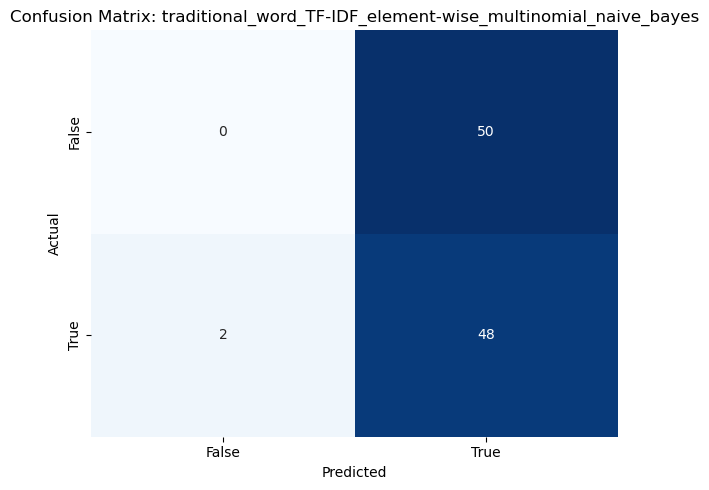

In [54]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [55]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
    mlflow.log_param("alpha", top_alpha)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_element-wise_multinomial_naive_bayes at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/90d00563c1194a8d8f1d6fbfd4618b74
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Logistic regression

In [56]:
classifier_name = "logistic_regression"

Resolving the penalty parameter - for both types only certain solvers are possible

In [57]:
logigistic_regression_config = ClassifierConfig(
    classifier_object=LogisticRegression,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "penalty": lambda trial: trial.suggest_categorical("penalty", ["l1", "l2"]),
        "solver": lambda trial: trial.suggest_categorical("solver", ["liblinear", "saga"]),
    },
    fixed_hyperparameters={
        "max_iter": 5000,
        "n_jobs": -1 #uses all cores
    }
)

Set up the study

In [58]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-15 14:08:30,513] A new study created in RDB with name: authorship_verification_traditional_word_TF-IDF_element-wise_logistic_regression


In [59]:
study.optimize(lambda trial: objective(trial, logigistic_regression_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:08:31,705] Trial 0 finished with value: 57.0 and parameters: {'max_features': 100000, 'min_df': 0.005746289418854568, 'lowercase': False, 'sublinear_tf': False, 'C': 2.757605581040856, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 0 with value: 57.0.


Logging results 

Top f1: 57.0

Top accuracy: 61.36

Top precision: 50.94

Top recall: 55.67

Used hyperparameters 

max_features: 100000

min_df: 0.005746289418854568

lowercase: False

sublinear_tf: False

{'C': 2.757605581040856, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:08:32,773] Trial 1 finished with value: 53.0 and parameters: {'max_features': 50000, 'min_df': 0.00866665114602689, 'lowercase': True, 'sublinear_tf': False, 'C': 0.12179623760902761, 'penalty': 'l1', 'solver': 'saga'}. Best is trial 0 with value: 57.0.


Logging results 

Top f1: 53.0

Top accuracy: 53.0

Top precision: 100.0

Top recall: 69.28

Used hyperparameters 

max_features: 50000

min_df: 0.00866665114602689

lowercase: True

sublinear_tf: False

{'C': 0.12179623760902761, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: None

min_df: 0.006832488632072977

lowercase: True

sublinear_tf: True

{'C': 0.04425264475414804, 'penalty': 'l2', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
[I 2025-12-15 14:08:34,824] Trial 3 finished with value: 47.0 and parameters: {'max_features': 100000, 'min_df': 0.002052710539763383, 'lowercase': False, 'sublinear_tf': False, 'C': 0.7928687618438683, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 57.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 100000

min_df: 0.002052710539763383

lowercase: False

sublinear_tf: False

{'C': 0.7928687618438683, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1223: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 6.
  warnings.warn(
[I 2025-12-15 14:08:35,847] Trial 4 finished with value: 47.0 and parameters: {'max_features': 50000, 'min_df': 0.0006481985399729363, 'lowercase': True, 'sublinear_tf': True, 'C': 0.2346266548600352, 'penalty': 'l1', 'solver': 'liblinear'}. Best is trial 0 with value: 57.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 50000

min_df: 0.0006481985399729363

lowercase: True

sublinear_tf: True

{'C': 0.2346266548600352, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 5000, 'n_jobs': -1}


Save the study insights

In [60]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "max_iter": 5000,
    "n_jobs": -1
})

In [61]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")

trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [62]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf,C,penalty,solver,max_iter,n_jobs
0,0,57.0,61.36,50.94,55.67,100000.0,0.005746,False,False,2.757606,l1,saga,5000,-1
1,1,53.0,53.00,100.00,69.28,50000.0,0.008667,True,False,0.121796,l1,saga,5000,-1
2,2,47.0,0.00,0.00,0.00,NaN,0.006832,True,True,0.044253,l2,liblinear,5000,-1
3,3,47.0,0.00,0.00,0.00,100000.0,0.002053,False,False,0.792869,l1,liblinear,5000,-1
4,4,47.0,0.00,0.00,0.00,50000.0,0.000648,True,True,0.234627,l1,liblinear,5000,-1


In [63]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [64]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Logistic regression

In [65]:
best_params = {}
trial_results = {}

In [66]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [67]:
print(best_params)

{'max_features': 100000, 'min_df': 0.005746289418854568, 'lowercase': False, 'sublinear_tf': False, 'C': 2.757605581040856, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 5000, 'n_jobs': -1}


In [68]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [69]:
trial_results_df = pd.DataFrame(trial_results)

In [71]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_lowercase = best_params["lowercase"]
top_sublinear_tf  = best_params["sublinear_tf"]

top_c = best_params["C"]
top_penalty = best_params["penalty"]
top_solver = best_params["solver"]
top_max_iter = best_params["max_iter"]
top_n_jobs = best_params["n_jobs"]

In [72]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")
print(f"c: {top_c}\n")
print(f"penalty: {top_penalty}\n")
print(f"solver: {top_solver}\n")
print(f"max_iter: {top_max_iter}\n")
print(f"n_jobs: {top_n_jobs}\n")

Used hyperparameters 

max_features: 100000

min_df: 0.005746289418854568

lowercase: False

sublinear_tf: False

c: 2.757605581040856

penalty: l1

solver: saga

max_iter: 5000

n_jobs: -1



Reconstruct the best vectorizer

In [73]:
best_vectorizer = build_tfidf_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        lowercase=top_lowercase,
        sublinear_tf=top_sublinear_tf
        )

Combine validation and training dataset

In [74]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [75]:
train_data, test_data = build_tfidf_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [76]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [77]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [78]:
classifier = LogisticRegression(
    C=top_c,
    penalty=top_penalty,
    solver=top_solver,
    max_iter=top_max_iter,
    n_jobs=top_n_jobs
)
classifier.fit(train_data_diff, y_train)

LogisticRegression(C=2.757605581040856, max_iter=5000, n_jobs=-1, penalty='l1',
                   solver='saga')

Predict the labels for the test data

In [79]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [80]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 49.0

Top accuracy: 49.12

Top precision: 56.0

Top recall: 52.34



Save the final vectorizer and classifier

In [81]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_TF-IDF_element-wise_logistic_regression_best_model.pkl']

Confusion matrix

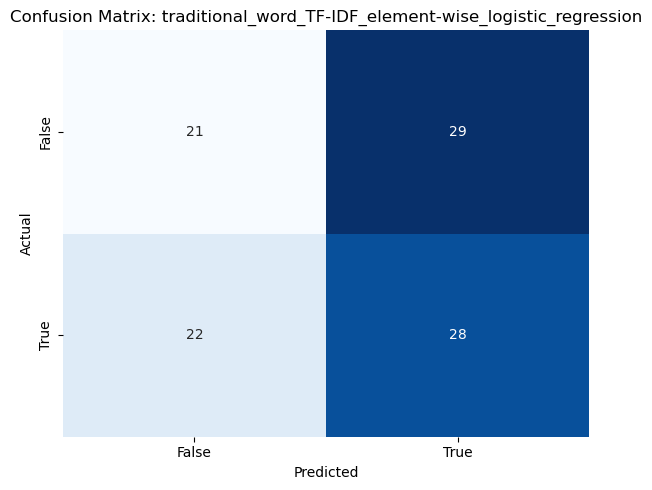

In [82]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [83]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
    
    mlflow.log_param("C", top_c)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("solver", top_solver)
    mlflow.log_param("max_iter", top_max_iter)
    mlflow.log_param("n_jobs", top_n_jobs)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_element-wise_logistic_regression at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/546f4adbd74a44df9b6d12cad0c65dc8
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Linear SVC

In [84]:
classifier_name = "linear_svc"

In [85]:
linear_svc_config = ClassifierConfig(
    classifier_object=LinearSVC,
    searched_hyperparameters={
        "C": lambda trial: trial.suggest_float("C", 0.01, 5.0, log=True),
        "loss": lambda trial: trial.suggest_categorical("loss", ["hinge", "squared_hinge"]),
        "class_weight": lambda trial: trial.suggest_categorical("class_weight", [None, "balanced"]),
    },
    fixed_hyperparameters={
        "penalty": "l2",       # LinearSVC ONLY supports l2
        "dual": True,          # for high-dimensional data (TF-IDF)
        "max_iter": 5000       # ensure convergence
    }
)

Set up the study

In [86]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-15 14:16:06,676] A new study created in RDB with name: authorship_verification_traditional_word_TF-IDF_element-wise_linear_svc


In [87]:
study.optimize(lambda trial: objective(trial, linear_svc_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:16:07,853] Trial 0 finished with value: 56.0 and parameters: {'max_features': 20000, 'min_df': 0.0016663320484605654, 'lowercase': False, 'sublinear_tf': False, 'C': 0.03523776891227623, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 0 with value: 56.0.


Logging results 

Top f1: 56.0

Top accuracy: 55.7

Top precision: 83.02

Top recall: 66.67

Used hyperparameters 

max_features: 20000

min_df: 0.0016663320484605654

lowercase: False

sublinear_tf: False

{'C': 0.03523776891227623, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:16:08,920] Trial 1 finished with value: 69.0 and parameters: {'max_features': 50000, 'min_df': 0.003004511214024141, 'lowercase': False, 'sublinear_tf': True, 'C': 0.5732896857717759, 'loss': 'hinge', 'class_weight': 'balanced'}. Best is trial 1 with value: 69.0.


Logging results 

Top f1: 69.0

Top accuracy: 66.18

Top precision: 84.91

Top recall: 74.38

Used hyperparameters 

max_features: 50000

min_df: 0.003004511214024141

lowercase: False

sublinear_tf: True

{'C': 0.5732896857717759, 'loss': 'hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 59.0

Top accuracy: 58.11

Top precision: 81.13

Top recall: 67.72

Used hyperparameters 

max_features: 100000

min_df: 0.0005959562758189335

lowercase: False

sublinear_tf: False

{'C': 0.05800632549748499, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:16:11,186] Trial 3 finished with value: 47.0 and parameters: {'max_features': 20000, 'min_df': 0.0027574921221449585, 'lowercase': False, 'sublinear_tf': False, 'C': 0.048436049012438254, 'loss': 'squared_hinge', 'class_weight': None}. Best is trial 1 with value: 69.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 20000

min_df: 0.0027574921221449585

lowercase: False

sublinear_tf: False

{'C': 0.048436049012438254, 'loss': 'squared_hinge', 'class_weight': None, 'penalty': 'l2', 'dual': True, 'max_iter': 5000}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:16:12,266] Trial 4 finished with value: 62.0 and parameters: {'max_features': 20000, 'min_df': 0.008185660481419743, 'lowercase': False, 'sublinear_tf': True, 'C': 0.10765501949930181, 'loss': 'squared_hinge', 'class_weight': 'balanced'}. Best is trial 1 with value: 69.0.


Logging results 

Top f1: 62.0

Top accuracy: 59.04

Top precision: 92.45

Top recall: 72.06

Used hyperparameters 

max_features: 20000

min_df: 0.008185660481419743

lowercase: False

sublinear_tf: True

{'C': 0.10765501949930181, 'loss': 'squared_hinge', 'class_weight': 'balanced', 'penalty': 'l2', 'dual': True, 'max_iter': 5000}


Save the study insights

In [88]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "penalty": "l2",       
    "dual": True,          
    "max_iter": 5000
})


In [89]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [90]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf,C,loss,class_weight,penalty,dual,max_iter
0,0,56.0,55.70,83.02,66.67,20000,0.001666,False,False,0.035238,squared_hinge,balanced,l2,True,5000
1,1,69.0,66.18,84.91,74.38,50000,0.003005,False,True,0.573290,hinge,balanced,l2,True,5000
2,2,59.0,58.11,81.13,67.72,100000,0.000596,False,False,0.058006,squared_hinge,balanced,l2,True,5000
3,3,47.0,0.00,0.00,0.00,20000,0.002757,False,False,0.048436,squared_hinge,None,l2,True,5000
4,4,62.0,59.04,92.45,72.06,20000,0.008186,False,True,0.107655,squared_hinge,balanced,l2,True,5000


In [91]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [92]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Linear SVC

In [93]:
best_params = {}
trial_results = {}

In [94]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [95]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [96]:
trial_results_df = pd.DataFrame(trial_results)

In [98]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_lowercase = best_params["lowercase"]
top_sublinear_tf  = best_params["sublinear_tf"]

top_c = best_params["C"]
top_loss = best_params["loss"]
top_class_weight = best_params["class_weight"]
top_penalty = best_params["penalty"]
top_dual = best_params["dual"]
top_max_iter = best_params["max_iter"]

In [99]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")

print(f"c: {top_c}\n")
print(f"loss: {top_loss}\n")
print(f"class_weight: {top_class_weight}\n")
print(f"penalty: {top_penalty}\n")
print(f"dual: {top_dual}\n")
print(f"max_iter: {top_max_iter}\n")

Used hyperparameters 

max_features: 50000

min_df: 0.003004511214024141

lowercase: False

sublinear_tf: True

c: 0.5732896857717759

loss: hinge

class_weight: balanced

penalty: l2

dual: True

max_iter: 5000



Reconstruct the best vectorizer

In [100]:
best_vectorizer = build_tfidf_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        lowercase=top_lowercase,
        sublinear_tf=top_sublinear_tf
        )

Combine validation and training dataset

In [101]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [102]:
train_data, test_data = build_tfidf_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [103]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [104]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [105]:
classifier = LinearSVC(
    C=top_c,
    loss=top_loss,
    class_weight=top_class_weight,
    penalty=top_penalty,
    dual=top_dual,
    max_iter=top_max_iter
)

classifier.fit(train_data_diff, y_train)

LinearSVC(C=0.5732896857717759, class_weight='balanced', dual=True,
          loss='hinge', max_iter=5000)

Predict the labels for the test data

In [106]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [107]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 49.0

Top accuracy: 49.49

Top precision: 98.0

Top recall: 65.77



Save the final vectorizer and classifier

In [108]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_TF-IDF_element-wise_linear_svc_best_model.pkl']

Confusion matrix

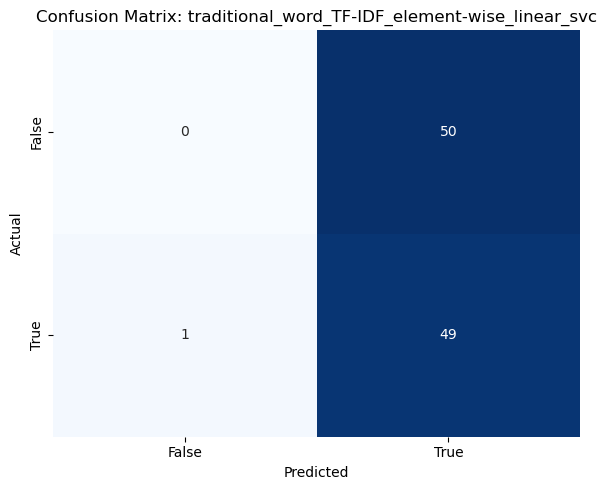

In [109]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [110]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
                    
    mlflow.log_param("C", top_c)
    mlflow.log_param("loss", top_loss)
    mlflow.log_param("class_weight", top_class_weight)
    mlflow.log_param("penalty", top_penalty)
    mlflow.log_param("dual", top_dual)
    mlflow.log_param("max_iter", top_max_iter)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_element-wise_linear_svc at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/dc7e4cd25d234fe7b8cbaf0adf50be89
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - K-nearest neighbors

In [111]:
classifier_name = "k-nearest_neighbors"

In [112]:
knn_config = ClassifierConfig(
    classifier_object=KNeighborsClassifier,
    searched_hyperparameters={
        "n_neighbors": lambda trial: trial.suggest_int("n_neighbors", 1, 50),
        "weights": lambda trial: trial.suggest_categorical("weights", ["uniform", "distance"]),
        "metric": lambda trial: trial.suggest_categorical("metric", ["euclidean", "manhattan", "cosine"]),
    },
    fixed_hyperparameters={
        "algorithm": "auto"
    }
)

Set up the study

In [113]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-15 14:20:05,527] A new study created in RDB with name: authorship_verification_traditional_word_TF-IDF_element-wise_k-nearest_neighbors


In [114]:
study.optimize(lambda trial: objective(trial, knn_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:06,752] Trial 0 finished with value: 47.0 and parameters: {'max_features': 100000, 'min_df': 0.007129387721338151, 'lowercase': False, 'sublinear_tf': True, 'n_neighbors': 26, 'weights': 'uniform', 'metric': 'manhattan'}. Best is trial 0 with value: 47.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 100000

min_df: 0.007129387721338151

lowercase: False

sublinear_tf: True

{'n_neighbors': 26, 'weights': 'uniform', 'metric': 'manhattan', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:07,799] Trial 1 finished with value: 47.0 and parameters: {'max_features': None, 'min_df': 0.0026909651314546306, 'lowercase': False, 'sublinear_tf': True, 'n_neighbors': 14, 'weights': 'uniform', 'metric': 'cosine'}. Best is trial 0 with value: 47.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: None

min_df: 0.0026909651314546306

lowercase: False

sublinear_tf: True

{'n_neighbors': 14, 'weights': 'uniform', 'metric': 'cosine', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 50000

min_df: 0.001173885536562927

lowercase: True

sublinear_tf: True

{'n_neighbors': 9, 'weights': 'distance', 'metric': 'euclidean', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:11,364] Trial 3 finished with value: 59.0 and parameters: {'max_features': None, 'min_df': 0.006449719978680492, 'lowercase': True, 'sublinear_tf': False, 'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan'}. Best is trial 3 with value: 59.0.


Logging results 

Top f1: 59.0

Top accuracy: 65.0

Top precision: 49.06

Top recall: 55.91

Used hyperparameters 

max_features: None

min_df: 0.006449719978680492

lowercase: True

sublinear_tf: False

{'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan', 'algorithm': 'auto'}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:13,979] Trial 4 finished with value: 47.0 and parameters: {'max_features': 100000, 'min_df': 0.0006423787399473129, 'lowercase': False, 'sublinear_tf': True, 'n_neighbors': 11, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 3 with value: 59.0.


Logging results 

Top f1: 47.0

Top accuracy: 0.0

Top precision: 0.0

Top recall: 0.0

Used hyperparameters 

max_features: 100000

min_df: 0.0006423787399473129

lowercase: False

sublinear_tf: True

{'n_neighbors': 11, 'weights': 'uniform', 'metric': 'euclidean', 'algorithm': 'auto'}


Save the study insights

In [115]:
best_trial = study.best_trial
best_params = best_trial.params

best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "algorithm": "auto"
})

In [116]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [117]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf,n_neighbors,weights,metric,algorithm
0,0,47.0,0.0,0.00,0.00,100000.0,0.007129,False,True,26,uniform,manhattan,auto
1,1,47.0,0.0,0.00,0.00,NaN,0.002691,False,True,14,uniform,cosine,auto
2,2,47.0,0.0,0.00,0.00,50000.0,0.001174,True,True,9,distance,euclidean,auto
3,3,59.0,65.0,49.06,55.91,NaN,0.006450,True,False,11,distance,manhattan,auto
4,4,47.0,0.0,0.00,0.00,100000.0,0.000642,False,True,11,uniform,euclidean,auto


In [118]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [119]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - K-nearest neighbors

In [120]:
best_params = {}
trial_results = {}

In [121]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [122]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [123]:
trial_results_df = pd.DataFrame(trial_results)

In [124]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_lowercase = best_params["lowercase"]
top_sublinear_tf  = best_params["sublinear_tf"]

top_n_neighbors = best_params["n_neighbors"]
top_weights = best_params["weights"]
top_metric = best_params["metric"]
top_algorithm = best_params["algorithm"]

In [125]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")

print(f"n_neighbors: {top_n_neighbors}\n")
print(f"weights: {top_weights}\n")
print(f"metric: {top_metric}\n")
print(f"algorithm: {top_algorithm}\n")

Used hyperparameters 

max_features: None

min_df: 0.006449719978680492

lowercase: True

sublinear_tf: False

n_neighbors: 11

weights: distance

metric: manhattan

algorithm: auto



Reconstruct the best vectorizer

In [126]:
best_vectorizer = build_tfidf_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        lowercase=top_lowercase,
        sublinear_tf=top_sublinear_tf
        )

Combine validation and training dataset

In [127]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [128]:
train_data, test_data = build_tfidf_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [129]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [130]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [131]:
classifier = KNeighborsClassifier(
    n_neighbors=top_n_neighbors,
    weights=top_weights,
    metric=top_metric,
    algorithm=top_algorithm
)

classifier.fit(train_data_diff, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=11, weights='distance')

Predict the labels for the test data

In [132]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [133]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 60.0

Top accuracy: 65.62

Top precision: 42.0

Top recall: 51.22



Save the final vectorizer and classifier

In [134]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_TF-IDF_element-wise_k-nearest_neighbors_best_model.pkl']

Confusion matrix

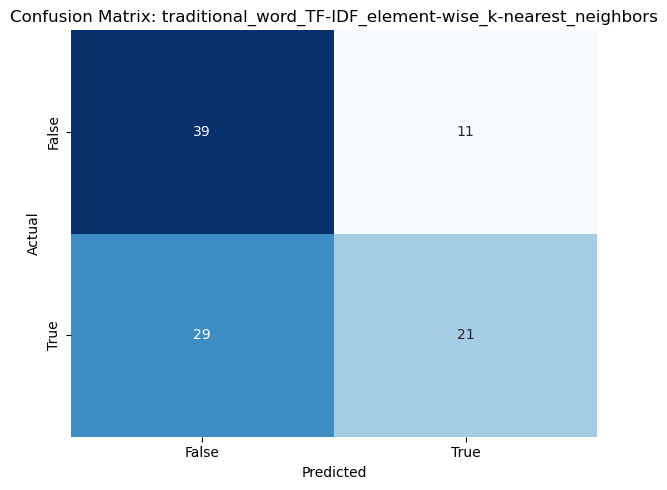

In [135]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [136]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublienar_tf", top_sublinear_tf)
                    
    mlflow.log_param("n_neighbors", top_n_neighbors)
    mlflow.log_param("weights", top_weights)
    mlflow.log_param("metric", top_metric)
    mlflow.log_param("algorithm", top_algorithm)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_element-wise_k-nearest_neighbors at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/c00d5b3f1a174cdfa02a7b11973267f2
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters - Random Forest

In [137]:
classifier_name = "random_forest"

In [138]:
random_forest_config = ClassifierConfig(
    classifier_object=RandomForestClassifier,
    searched_hyperparameters={
        "n_estimators": lambda trial: trial.suggest_int("n_estimators", 100, 600),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 5, 50),
        "min_samples_split": lambda trial: trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": lambda trial: trial.suggest_int("min_samples_leaf", 1, 10)
    },
    fixed_hyperparameters={
        "n_jobs": -1,        # use all cores
        "random_state": 42   # reproducible forests
    }
)

Set up the study

In [139]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-15 14:20:22,298] A new study created in RDB with name: authorship_verification_traditional_word_TF-IDF_element-wise_random_forest


In [140]:
study.optimize(lambda trial: objective(trial, random_forest_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:24,601] Trial 0 finished with value: 54.0 and parameters: {'max_features': 50000, 'min_df': 0.006202502409268303, 'lowercase': True, 'sublinear_tf': True, 'n_estimators': 452, 'max_depth': 43, 'min_samples_split': 8, 'min_samples_leaf': 8}. Best is trial 0 with value: 54.0.


Logging results 

Top f1: 54.0

Top accuracy: 65.22

Top precision: 28.3

Top recall: 39.47

Used hyperparameters 

max_features: 50000

min_df: 0.006202502409268303

lowercase: True

sublinear_tf: True

{'n_estimators': 452, 'max_depth': 43, 'min_samples_split': 8, 'min_samples_leaf': 8, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:26,486] Trial 1 finished with value: 58.0 and parameters: {'max_features': None, 'min_df': 0.004324120304507927, 'lowercase': False, 'sublinear_tf': False, 'n_estimators': 324, 'max_depth': 38, 'min_samples_split': 11, 'min_samples_leaf': 10}. Best is trial 1 with value: 58.0.


Logging results 

Top f1: 58.0

Top accuracy: 78.95

Top precision: 28.3

Top recall: 41.67

Used hyperparameters 

max_features: None

min_df: 0.004324120304507927

lowercase: False

sublinear_tf: False

{'n_estimators': 324, 'max_depth': 38, 'min_samples_split': 11, 'min_samples_leaf': 10, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 54.0

Top accuracy: 66.67

Top precision: 26.42

Top recall: 37.84

Used hyperparameters 

max_features: 50000

min_df: 0.007025727081990014

lowercase: True

sublinear_tf: True

{'n_estimators': 220, 'max_depth': 33, 'min_samples_split': 18, 'min_samples_leaf': 9, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:30,676] Trial 3 finished with value: 52.0 and parameters: {'max_features': 50000, 'min_df': 0.0037618976783678417, 'lowercase': True, 'sublinear_tf': False, 'n_estimators': 519, 'max_depth': 39, 'min_samples_split': 2, 'min_samples_leaf': 10}. Best is trial 1 with value: 58.0.


Logging results 

Top f1: 52.0

Top accuracy: 69.23

Top precision: 16.98

Top recall: 27.27

Used hyperparameters 

max_features: 50000

min_df: 0.0037618976783678417

lowercase: True

sublinear_tf: False

{'n_estimators': 519, 'max_depth': 39, 'min_samples_split': 2, 'min_samples_leaf': 10, 'n_jobs': -1, 'random_state': 42}
Fitting vectorizer 

Transforming texts with vectorizer



[I 2025-12-15 14:20:33,066] Trial 4 finished with value: 47.0 and parameters: {'max_features': None, 'min_df': 0.0016851656010218932, 'lowercase': True, 'sublinear_tf': True, 'n_estimators': 542, 'max_depth': 31, 'min_samples_split': 17, 'min_samples_leaf': 8}. Best is trial 1 with value: 58.0.


Logging results 

Top f1: 47.0

Top accuracy: 50.0

Top precision: 15.09

Top recall: 23.19

Used hyperparameters 

max_features: None

min_df: 0.0016851656010218932

lowercase: True

sublinear_tf: True

{'n_estimators': 542, 'max_depth': 31, 'min_samples_split': 17, 'min_samples_leaf': 8, 'n_jobs': -1, 'random_state': 42}


Save the study insights

In [141]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "n_jobs": -1,        
    "random_state": 42   
})


In [142]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [143]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf,n_estimators,max_depth,min_samples_split,min_samples_leaf,n_jobs,random_state
0,0,54.0,65.22,28.30,39.47,50000.0,0.006203,True,True,452,43,8,8,-1,42
1,1,58.0,78.95,28.30,41.67,NaN,0.004324,False,False,324,38,11,10,-1,42
2,2,54.0,66.67,26.42,37.84,50000.0,0.007026,True,True,220,33,18,9,-1,42
3,3,52.0,69.23,16.98,27.27,50000.0,0.003762,True,False,519,39,2,10,-1,42
4,4,47.0,50.00,15.09,23.19,NaN,0.001685,True,True,542,31,17,8,-1,42


In [144]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [145]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - Random forest

In [146]:
best_params = {}
trial_results = {}

In [147]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [148]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [149]:
trial_results_df = pd.DataFrame(trial_results)

In [150]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_lowercase = best_params["lowercase"]
top_sublinear_tf  = best_params["sublinear_tf"]

top_n_estimators = best_params["n_estimators"]
top_max_depth = best_params["max_depth"]
top_min_samples_split = best_params["min_samples_split"]
top_min_samples_leaf = best_params["min_samples_leaf"]
top_n_jobs = best_params["n_jobs"]
top_random_state = best_params["random_state"]

In [151]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")

print(f"n_estimators: {top_n_estimators}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"min_samples_split: {top_min_samples_split}\n")
print(f"min_samples_leaf: {top_min_samples_leaf}\n")
print(f"n_jobs: {top_n_jobs}\n")
print(f"random_state: {top_random_state}\n")

Used hyperparameters 

max_features: None

min_df: 0.004324120304507927

lowercase: False

sublinear_tf: False

n_estimators: 324

max_depth: 38

min_samples_split: 11

min_samples_leaf: 10

n_jobs: -1

random_state: 42



Reconstruct the best vectorizer

In [152]:
best_vectorizer = build_tfidf_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        lowercase=top_lowercase,
        sublinear_tf=top_sublinear_tf
        )

Combine validation and training dataset

In [153]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [154]:
train_data, test_data = build_tfidf_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [155]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [156]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [157]:
classifier = RandomForestClassifier(
    n_estimators=top_n_estimators,
    max_depth=top_max_depth,
    min_samples_split=top_min_samples_split,
    min_samples_leaf=top_min_samples_leaf,
    n_jobs=top_n_jobs,
    random_state=top_random_state
)

classifier.fit(train_data_diff, y_train)

RandomForestClassifier(max_depth=38, min_samples_leaf=10, min_samples_split=11,
                       n_estimators=324, n_jobs=-1, random_state=42)

Predict the labels for the test data

In [158]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [159]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 59.0

Top accuracy: 57.38

Top precision: 70.0

Top recall: 63.06



Save the final vectorizer and classifier

In [160]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_TF-IDF_element-wise_random_forest_best_model.pkl']

Confusion matrix

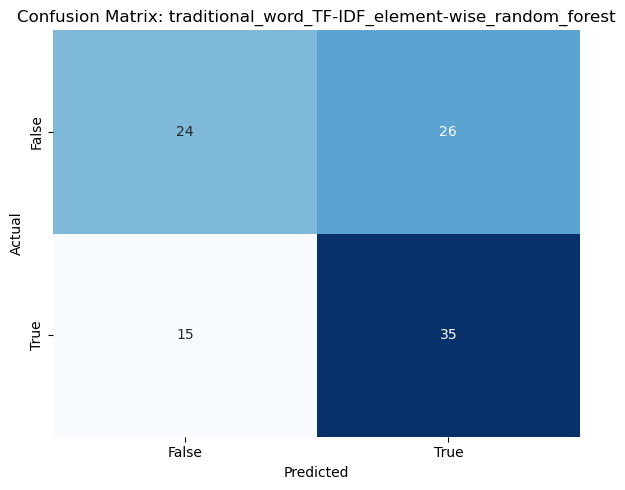

In [161]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [162]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
                    
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("min_samples_split", top_min_samples_split)
    mlflow.log_param("min_samples_leaf", top_min_samples_leaf)
    mlflow.log_param("n_jobs", top_n_jobs)
    mlflow.log_param("random_state", top_random_state)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_element-wise_random_forest at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/2f6e5c71d59e4cf5b53d00e0bb1903b4
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040


# Evaluate model hyperparameters- XGBoost

In [163]:
classifier_name = "xgboost"

In [164]:
xgboost_config = ClassifierConfig(
    classifier_object=XGBClassifier,
    searched_hyperparameters={
        "eta": lambda trial: trial.suggest_float("eta", 0.01, 0.3),
        "max_depth": lambda trial: trial.suggest_int("max_depth", 3, 12),
        "subsample": lambda trial: trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": lambda trial: trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": lambda trial: trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": lambda trial: trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
    },
    fixed_hyperparameters={
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "n_estimators": 300,     
        "tree_method": "auto", 
        "use_label_encoder": False
    }
)

Set up the study

In [165]:
optuna_study_path = f"sqlite:///optuna_study_{developer_initials}_{representation_type}_{classifier_name}"

study = optuna.create_study(
    study_name=f"authorship_verification_{representation_type}_{classifier_name}",
    storage=optuna_study_path,
    direction="maximize",
    load_if_exists=True
)

[I 2025-12-15 14:20:42,519] A new study created in RDB with name: authorship_verification_traditional_word_TF-IDF_element-wise_xgboost


In [166]:
study.optimize(lambda trial: objective(trial, xgboost_config), n_trials=30)

Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:20:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-15 14:20:44,554] Trial 0 finished with value: 53.0 and parameters: {'max_features': 100000, 'min_df': 0.0027966584897352173, 'lowercase': False, 'sublinear_tf': True, 'eta': 0.06806516472046356, 'max_depth': 8, 'subsample': 0.712853865393646, 'colsample_bytree': 0.562463118016076, 'reg_lambda': 0.028572242640100394, 'reg_alpha': 0.009823762711416563}. Best is trial 0 with value: 53.0.


Logging results 

Top f1: 53.0

Top accuracy: 58.33

Top precision: 39.62

Top recall: 47.19

Used hyperparameters 

max_features: 100000

min_df: 0.0027966584897352173

lowercase: False

sublinear_tf: True

{'eta': 0.06806516472046356, 'max_depth': 8, 'subsample': 0.712853865393646, 'colsample_bytree': 0.562463118016076, 'reg_lambda': 0.028572242640100394, 'reg_alpha': 0.009823762711416563, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:20:45] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-15 14:20:46,147] Trial 1 finished with value: 54.0 and parameters: {'max_features': 20000, 'min_df': 0.008998066914473064, 'lowercase': True, 'sublinear_tf': False, 'eta': 0.10375913892460419, 'max_depth': 9, 'subsample': 0.8988875328541306, 'colsample_bytree': 0.5583672634301418, 'reg_lambda': 0.16596584858204863, 'reg_alpha': 0.00874935893409933}. Best is trial 1 with value: 54.0.


Logging results 

Top f1: 54.0

Top accuracy: 62.96

Top precision: 32.08

Top recall: 42.5

Used hyperparameters 

max_features: 20000

min_df: 0.008998066914473064

lowercase: True

sublinear_tf: False

{'eta': 0.10375913892460419, 'max_depth': 9, 'subsample': 0.8988875328541306, 'colsample_bytree': 0.5583672634301418, 'reg_lambda': 0.16596584858204863, 'reg_alpha': 0.00874935893409933, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



...

Logging results 

Top f1: 56.0

Top accuracy: 68.0

Top precision: 32.08

Top recall: 43.59

Used hyperparameters 

max_features: None

min_df: 0.006184597676557804

lowercase: True

sublinear_tf: True

{'eta': 0.04931068383321608, 'max_depth': 9, 'subsample': 0.5487669959461801, 'colsample_bytree': 0.7828780384327608, 'reg_lambda': 0.023402859252498277, 'reg_alpha': 0.8207893281132789, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:20:49] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-15 14:20:49,713] Trial 3 finished with value: 50.0 and parameters: {'max_features': 20000, 'min_df': 0.00939052883758738, 'lowercase': False, 'sublinear_tf': True, 'eta': 0.08285432935268029, 'max_depth': 5, 'subsample': 0.7748738858631963, 'colsample_bytree': 0.5728191156510511, 'reg_lambda': 0.002812058064034456, 'reg_alpha': 0.007914396087768397}. Best is trial 2 with value: 56.0.


Logging results 

Top f1: 50.0

Top accuracy: 55.56

Top precision: 28.3

Top recall: 37.5

Used hyperparameters 

max_features: 20000

min_df: 0.00939052883758738

lowercase: False

sublinear_tf: True

{'eta': 0.08285432935268029, 'max_depth': 5, 'subsample': 0.7748738858631963, 'colsample_bytree': 0.5728191156510511, 'reg_lambda': 0.002812058064034456, 'reg_alpha': 0.007914396087768397, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}
Fitting vectorizer 

Transforming texts with vectorizer



/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:20:50] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2025-12-15 14:20:51,596] Trial 4 finished with value: 59.0 and parameters: {'max_features': 50000, 'min_df': 0.0032980425822931557, 'lowercase': True, 'sublinear_tf': False, 'eta': 0.20206422619390624, 'max_depth': 5, 'subsample': 0.6773614616156562, 'colsample_bytree': 0.7390371655158993, 'reg_lambda': 0.009335746189976185, 'reg_alpha': 0.002015942437429113}. Best is trial 4 with value: 59.0.


Logging results 

Top f1: 59.0

Top accuracy: 64.29

Top precision: 50.94

Top recall: 56.84

Used hyperparameters 

max_features: 50000

min_df: 0.0032980425822931557

lowercase: True

sublinear_tf: False

{'eta': 0.20206422619390624, 'max_depth': 5, 'subsample': 0.6773614616156562, 'colsample_bytree': 0.7390371655158993, 'reg_lambda': 0.009335746189976185, 'reg_alpha': 0.002015942437429113, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'n_estimators': 300, 'tree_method': 'auto', 'use_label_encoder': False}


Save the study insights

In [167]:
best_trial = study.best_trial
best_params = best_trial.params
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "n_estimators": 300,     
    "tree_method": "auto", 
    "use_label_encoder": False
})

In [168]:
trial_results_path = current_dir.parent.parent / "data" / "02_models" / "traditional" / f"{developer_initials}_{representation_type}_{classifier_name}_trial_results.json"
finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_parameters.json"
finetuned_vectorizer_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_vectorizer.pkl"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / "traditional" /f"{developer_initials}_{representation_type}_{classifier_name}_best_model.pkl"

Load the trial data

In [169]:
trial_rows = []

for trial in study.trials:
    
    if "results" not in trial.user_attrs:
        continue 
        
    metrics = trial.user_attrs["results"]["metrics"]
    hyper_params = trial.user_attrs["results"]["hyperparameters"]
    classifier_hyper_params = trial.user_attrs["results"]["classifier_hyperparameters"]
    
    row = {
        "trial_number": trial.number,
        "top_f1": metrics["top_f1"],
        "top_accuracy": metrics["top_accuracy"],
        "top_precision": metrics["top_precision"],
        "top_recall": metrics["top_recall"],
        
        **{f"{key}": v for key, v in hyper_params.items()},
        **{f"{key}": v for key, v in classifier_hyper_params.items()},
        
    }
    trial_rows.append(row)

trial_results_df = pd.DataFrame(trial_rows)
trial_results_df.head()

,trial_number,top_f1,top_accuracy,top_precision,top_recall,max_features,min_df,lowercase,sublinear_tf,eta,max_depth,subsample,colsample_bytree,reg_lambda,reg_alpha,objective,eval_metric,n_estimators,tree_method,use_label_encoder
0,0,53.0,58.33,39.62,47.19,100000.0,0.002797,False,True,0.068065,8,0.712854,0.562463,0.028572,0.009824,binary:logistic,logloss,300,auto,False
1,1,54.0,62.96,32.08,42.50,20000.0,0.008998,True,False,0.103759,9,0.898888,0.558367,0.165966,0.008749,binary:logistic,logloss,300,auto,False
2,2,56.0,68.00,32.08,43.59,NaN,0.006185,True,True,0.049311,9,0.548767,0.782878,0.023403,0.820789,binary:logistic,logloss,300,auto,False
3,3,50.0,55.56,28.30,37.50,20000.0,0.009391,False,True,0.082854,5,0.774874,0.572819,0.002812,0.007914,binary:logistic,logloss,300,auto,False
4,4,59.0,64.29,50.94,56.84,50000.0,0.003298,True,False,0.202064,5,0.677361,0.739037,0.009336,0.002016,binary:logistic,logloss,300,auto,False


In [170]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

In [171]:
with open(trial_results_path, "w") as f:
    json.dump(trial_results_df.to_dict(orient="records"), f, indent=4)

# Train the final model - XGBoost

In [172]:
best_params = {}
trial_results = {}

In [173]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [174]:
with open(trial_results_path, "r") as f:
    trial_results = json.load(f)

In [175]:
trial_results_df = pd.DataFrame(trial_results)

In [176]:
top_max_features = best_params["max_features"]
top_min_df = best_params["min_df"]
top_lowercase = best_params["lowercase"]
top_sublinear_tf  = best_params["sublinear_tf"]

top_eta = best_params["eta"]
top_max_depth = best_params["max_depth"]
top_subsample = best_params["subsample"]
top_colsample_bytree = best_params["colsample_bytree"]
top_reg_lambda = best_params["reg_lambda"]
top_reg_alpha = best_params["reg_alpha"]
top_objective = best_params["objective"]
top_eval_metric = best_params["eval_metric"]
top_n_estimators = best_params["n_estimators"]
top_tree_method = best_params["tree_method"]
top_use_label_encoder = best_params["use_label_encoder"]

In [177]:
print(f"Used hyperparameters \n")
print(f"max_features: {top_max_features}\n")
print(f"min_df: {top_min_df}\n")
print(f"lowercase: {top_lowercase}\n")
print(f"sublinear_tf: {top_sublinear_tf}\n")

print(f"eta: {top_eta}\n")
print(f"max_depth: {top_max_depth}\n")
print(f"subsample: {top_subsample}\n")
print(f"colsample_bytree: {top_colsample_bytree}\n")
print(f"reg_lambda: {top_reg_lambda}\n")
print(f"reg_alpha: {top_reg_alpha}\n")
print(f"objective: {top_objective}\n")
print(f"eval_metric: {top_eval_metric}\n")
print(f"n_estimators: {top_n_estimators}\n")
print(f"tree_method: {top_tree_method}\n")
print(f"use_label_encoder: {top_use_label_encoder}\n")

Used hyperparameters 

max_features: 50000

min_df: 0.0032980425822931557

lowercase: True

sublinear_tf: False

eta: 0.20206422619390624

max_depth: 5

subsample: 0.6773614616156562

colsample_bytree: 0.7390371655158993

reg_lambda: 0.009335746189976185

reg_alpha: 0.002015942437429113

objective: binary:logistic

eval_metric: logloss

n_estimators: 300

tree_method: auto

use_label_encoder: False



Reconstruct the best vectorizer

In [178]:
best_vectorizer = build_tfidf_vectorizer(
        max_features=top_max_features,
        min_df=top_min_df, 
        lowercase=top_lowercase,
        sublinear_tf=top_sublinear_tf
        )

Combine validation and training dataset

In [179]:
final_train_df = pd.concat(
    [train_data_df, val_data_df],
    ignore_index=True
)

Fit the vectorizer and create features of training and test data

In [180]:
train_data, test_data = build_tfidf_features(best_vectorizer, final_train_df, test_data_df)

Fitting vectorizer 

Transforming texts with vectorizer



Compute the absolute differences between the pairs of features in train and test data

In [181]:
train_data_diff = compute_element_wise_features(train_data)
test_data_diff = compute_element_wise_features(test_data)

Get the labels for train and test data

In [182]:
y_train = final_train_df["same"].values
y_test = test_data_df["same"].values

Fit the classifier

In [183]:
classifier = XGBClassifier(
    eta=top_eta,
    max_depth=top_max_depth,
    subsample=top_subsample,
    colsample_bytree=top_colsample_bytree,
    reg_lambda=top_reg_lambda,
    reg_alpha=top_reg_alpha,
    objective=top_objective,
    eval_metric=top_eval_metric,
    n_estimators=top_n_estimators,
    tree_method=top_tree_method,
    use_label_encoder=top_use_label_encoder
    
)

classifier.fit(train_data_diff, y_train)

/opt/conda/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [14:20:53] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7390371655158993, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eta=0.20206422619390624, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, ...)

Predict the labels for the test data

In [184]:
y_pred = classifier.predict(test_data_diff)

Evaluate the results of the final classifier

In [185]:
top_f1, top_accuracy, top_precision, top_recall = evaluate_results(y_test, y_pred)

print(f"Logging results \n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Logging results 

Top f1: 57.0

Top accuracy: 55.93

Top precision: 66.0

Top recall: 60.55



Save the final vectorizer and classifier

In [186]:
joblib.dump(best_vectorizer, finetuned_vectorizer_path)
joblib.dump(classifier, finetuned_model_path)

['/home/jovyan/authorship_verification_dt/data/02_models/traditional/JP_traditional_word_TF-IDF_element-wise_xgboost_best_model.pkl']

Confusion matrix

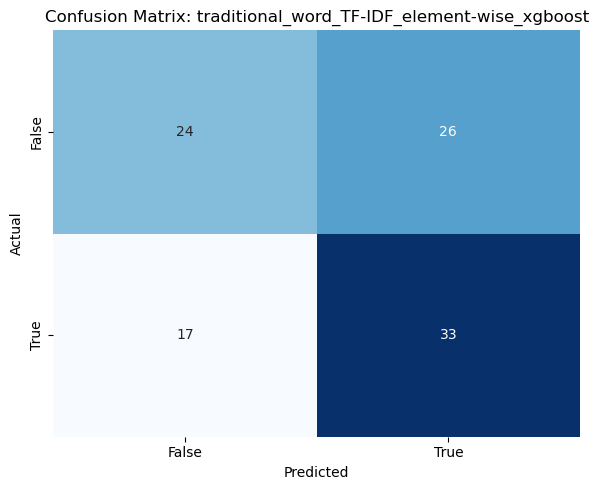

In [187]:
cm_fig = plot_confusion_matrix(y_test , y_pred, f"{representation_type}_{classifier_name}", labels=[False, True])

Log model information + metrics + results table + confusion matrix

In [188]:
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{representation_type}_{classifier_name}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("representation_type", representation_type )
    mlflow.log_param("classifier", classifier_name)
    mlflow.log_table(data=trial_results_df, artifact_file="trial_results.json")
    
    mlflow.log_param("max_features", top_max_features)
    mlflow.log_param("min_df", top_min_df)
    mlflow.log_param("lowercase", top_lowercase)
    mlflow.log_param("sublinear_tf", top_sublinear_tf)
                    
    mlflow.log_param("eta", top_eta)
    mlflow.log_param("max_depth", top_max_depth)
    mlflow.log_param("subsample", top_subsample)
    mlflow.log_param("colsample_bytree", top_colsample_bytree)
    mlflow.log_param("reg_lambda", top_reg_lambda)
    mlflow.log_param("reg_alpha", top_reg_alpha)
    mlflow.log_param("objective", top_objective)
    mlflow.log_param("eval_metric", top_eval_metric)
    mlflow.log_param("n_estimators", top_n_estimators)
    mlflow.log_param("tree_method", top_tree_method)
    mlflow.log_param("use_label_encoder", top_use_label_encoder)

    mlflow.log_metric("top_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(cm_fig, "confusion_matrix-test_data.png")

🏃 View run JP_traditional_word_TF-IDF_element-wise_xgboost at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/263ba29ae3ac4c22a3413b604a469e31
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
